# Class 11: Data visualization continued

Plan for today:
- Review and discuss additional features of using matplotlib to visualize data
- Data visualization using seaborn



### Downloading the data for today's class

Please run the code in the cell below to download the data for today's class.

In [2]:
import YData

# YData.download.download_class_code(11)   # get class code    
# YData.download.download_class_code(11, True)  # get the code with the answers 
# YData.download.download_homework(5)  # downloads the homework 

YData.download_data("movies.csv")
YData.download_data("movie_ratings.csv")


In [3]:
## If you are using Google Colabs, you should install the YData packages and mount the your google drive by uncommenting and running the code below.

# !pip install https://github.com/yuejiechi/YData_package/tarball/master
# from google.colab import drive
# drive.mount('/content/drive')


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

## Bechdel movies revisited

The code below reads in the Bechdel into a pandas DataFrame named `movies` from a .csv file, and reduces the data to a subset of relevant columns (this is the same code as was used in previous classes, although hopefully now you understand what it is doing!). 

In [5]:

movies = pd.read_csv("movies.csv")

col_names_to_keep = ['year', 'imdb', 'title', 'clean_test', 'binary', 'budget',
       'domgross', 'budget_2013', 'domgross_2013', 'decade_code', 'imdb_id',
       'rated', 'imdb_rating', 'runtime',  'imdb_votes']

movies =   movies[col_names_to_keep]

#movies.dropna(axis = 0, how = 'any', inplace = True, subset=col_names_to_keep[0:9])

movies.head()

,year,imdb,title,clean_test,binary,budget,domgross,budget_2013,domgross_2013,decade_code,imdb_id,rated,imdb_rating,runtime,imdb_votes
0,2013,tt1711425,21 &amp; Over,notalk,FAIL,13000000,25682380.0,13000000,25682380.0,1.0,1711425,NaN,NaN,NaN,NaN
1,2012,tt1343727,Dredd 3D,ok,PASS,45000000,13414714.0,45658735,13611086.0,1.0,1343727,NaN,NaN,NaN,NaN
2,2013,tt2024544,12 Years a Slave,notalk,FAIL,20000000,53107035.0,20000000,53107035.0,1.0,2024544,R,8.3,134 min,"143,446"
3,2013,tt1272878,2 Guns,notalk,FAIL,61000000,75612460.0,61000000,75612460.0,1.0,1272878,R,6.8,109 min,"87,301"
4,2013,tt0453562,42,men,FAIL,40000000,95020213.0,40000000,95020213.0,1.0,453562,PG-13,7.6,128 min,"43,608"


## Data visualization continued!

Let's now continue reviewing and learnign new features for how to use matplotlib package to visualize data.

### Visualzing catagorical data with subplots

The code below recreates our `bechdel_stats` DataFrame from the `movies` DataFrame (first warm-up exercise from last class). The `bechdel_stats` that has statistics calculated separately for movies that failed and movies that passed the Bechdel test; i.e., `bechdel_stats` DataFrame has two rows, the first row for movies that failed the Bechdel test and one for movies that passed the Bechdel test. 

The `bechdel_stats` also has the following columns: 

- `mean_revenue`: The mean revenue (domgross_2013) in 2013 inflation adjusted dollars
- `mean_budget`: The mean budget (budget_2013) in 2013 inflation adjusted dollars
- `n`: The number of movies 

In [6]:
# 1: Get mean budget, mean revenue, and number of movies for movies that passed and did not pass the Bechdel test 
bechdel_stats = movies.groupby("binary").agg(n = ("title", "count"),
                                             mean_revenue = ("domgross_2013", "mean"),
                                             mean_budget = ("budget_2013", "mean"))

bechdel_stats

,n,mean_revenue,mean_budget
binary,,,
FAIL,991,1.077744e+08,6.291156e+07
PASS,803,7.959192e+07,4.627417e+07


## Scatter plots

We can create a simple scatter plots using: `plt.plot()`

For more complex scatter plots we can use: `plot.scatter()`

Let's now create a DataFrame called `movies2` which is the same as our `movies` DataFrame but it also has an additional column called `after2000`. We will use this column to plots points before the year 2000 in a different color than points after 2000. 

In particular, the `after2000` column should be set to the string "red" for movies that occur before 2000 and to the string "green" for points that occured after 2000. 

We can then use the `plt.scatter()` function to plot data colored by whether a movie was made before or after 2000.

Do the results show anything interesting/interpretable? 


In [10]:
# Add a column called "before2000" which has values that are 
# "green" for years before 2000, "red" for years after 2000

movies2 = movies.copy()

movies2["before2000"] = "red"
boolean_after_2020 = movies2.year > 2000
movies2.loc[boolean_after_2020, "before2000"] = "green"

# display first and last row
movies2.iloc[[0, -1]]


In [ ]:
plt.scatter(movies2.budget_2013, movies2.domgross_2013, 
            color = movies2["before2000"], 
            alpha = .1);

plt.xlabel("Budget");
plt.ylabel("Revenue");


## Subplots

There are two ways to create subplots in matplotlib using either:

1. The pyplot interface
2. The axes interface

To create subplots using the pyplot interface we can use the `subplot` function:

- `plt.subplot(num_rows, num_cols, curr_plot_num);`
- `plt.plot(x, y);`


In [11]:
# reset the index to make "binary" a column in the DataFrame




# change the figure size





# subplots





In [12]:
# using the axes interface



# set the figure size




# subplots





## Using matplotlib as a general canvas

We can use matplotlib as a general canvas to create illustrations as well. For example, in my YData baseball class we drew a baseball diamond and updated where runners were on base.

Let's explore this very briefly...


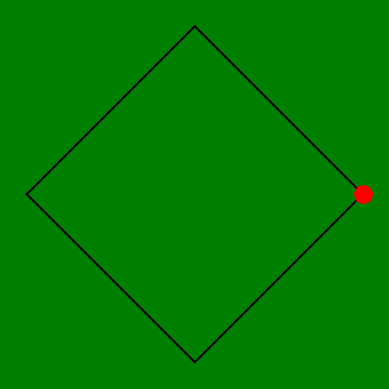

In [13]:
        
# draw the baseball diamond
plt.plot([0, 1], [0, 1], color = "black");
plt.plot([1, 0], [1, 2], color = "black");
plt.plot([0, -1], [2, 1], color = "black");
plt.plot([-1, 0], [1, 0], color = "black");

# make the axes square
plt.axis("square");

# put a runner on first
plt.plot([1], [1], color = "red", marker=".", markersize=25);

# turn off the axis
plt.axis("off");

# make the field green 
plt.gcf().set_facecolor('green')      # a better hexadecimal green: '#86eb34'

## Seaborn!

[Seaborn](https://seaborn.pydata.org/index.html) is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics. 

I.e., it is built on top of of matplotlib but produces better looking plots that are easier to create. 

Let's start by examining different themes which can produce better looking plots. We can do this using the `sns.set_theme()` method. 


### Movie revenue as a function of year

Using our `movies` DataFrame, let's create a DataFrame called `year_revenue` that has a row for each year a movie was released (`year` column) and has the following variables:

1. `mean_revenue_2013`: The mean revenue in 2013 inflation adjusted dollars
2. `mean_revenue`: The mean revenue in non-inflation adjusted dollars
3. `n`: The number of movies in our data set for each year


Once we have created the `year_revenue`, plot the `mean_revenue_2013` and the `mean_revenue` as a function of the year. 


In [ ]:

# Create the year_revenue DataFrame
year_revenue = movies.groupby("year").agg(
    mean_revenue_2013 = ("domgross_2013", "mean"),
    mean_revenue = ("domgross", "mean") ,
    n = ("domgross", "count")
)


# Visualize the time series
plt.plot(year_revenue["mean_revenue_2013"], ".-", label = "Inflation adjusted");
plt.plot(year_revenue["mean_revenue"], ".-", label = "Raw");
plt.legend();
plt.ylabel("Revenue ($)");


In [14]:
# Import seaborn
import seaborn as sns

# Apply the default theme




# Side note: Matplotlib also has themes
# plt.style.available
# plt.style.use('fivethirtyeight')


# Re-create a line plot of movie revenue over time here





### Plotting relationships between two quantitative variables

We can plot relationships between two quantitative variables using the `sns.relplot()` function


In [15]:
# plot relationship between budget and revenue (domgross_2013)



#### Penguins!

Let's continue to explore the relplot using data on penguins. 

We will also look at mapping other features of our data onto visual properties including: 
- `x`, and `y` column names to be plotted (as we have done before)
- `hue`: The column name to be mapped to the color of the points
- `size`: The column name to be mapped to the size of points
- `style`: The column name to be mapped to the style of the markers
- `col`: fThe column name to be mapped to faceting to compare multiple subplots


In [16]:
# Let's look at some penguins
penguins = sns.load_dataset("penguins")

print(type(penguins))

penguins.head()


<class 'pandas.core.frame.DataFrame'>


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [17]:
# plotting bill size on x, and y axes and other properties








### Plotting a single quantitative variable

We can plot a single quantitative variables using the `sns.displot()` function.

Properties we can set include
- `x`: The name of the data column you want to plot
- `hue`: The name of the column that colors each point
- `kind` The type of plot

Different options for `kind` are: “hist”, “kde”, “ecdf”


In [18]:
# plot the flipper length






### Plotting a quantitative variable for different categorical variable levels

We can plot a quantitative variable for different categorical variable levels using the `sns.catplot()` function.

We specify: 
- `x`: Cateogoral x-value column name
- `y`: Quantitative y-value column name
- `kind`: The type of plot

The `kind` argument can be set to the following: “strip”, “swarm”, “box”, “violin”, “boxen”, “point”, “bar”, or “count”


In [19]:
# plot flipper length for the different species using different kinds of plots






# also try “strip”, “swarm”, “box”, “violin”, “boxen”, “point”, or “bar”

### Pairs plots

One of the most useful visualizations for exploring the relationships between several quantitative variables is to create a "pairs plot" which creates a series of scatter plots between all quantitative variables in the data. 

We can do this in seaborn using the `sns.pairplot(data)` function!


In [20]:
# Create pair plots for the different varaibles in the penguins data set



<img src = "https://i.imgflip.com/1ezfdq.jpg">